# Прогнозирование стоимости недвижимости

**Датасет:** Zingat — объявления о недвижимости в Турции (`real_estate_data.csv`)

**Задача:** построить и сравнить несколько моделей регрессии, которые предсказывают
цену объекта недвижимости по его характеристикам.

**Целевая переменная:** `price` — цена продажи или месячная плата за аренду.

**План работы:**

| Этап | Что делаем |
|---|---|
| Этап 1 | Исследование данных (EDA) |
| Этап 2 | Предобработка данных |
| Этап 3 | Построение и сравнение моделей регрессии |
| Этап 4 | Сохранение модели для приложения |
| Этап 5 | Проверка модели на тестовых объектах |

Отдельное внимание уделяем **ансамблевым методам** (бэггинг, бустинг, стекинг) —
именно они дают основной прирост качества.

## 0. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# фиксируем случайность, чтобы результаты можно было повторить
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Библиотеки загружены')

Библиотеки загружены


---
# Этап 1. Исследование данных (EDA)

## 1.1 Знакомство с данными

Данные взяты с площадки **Zingat** — это турецкий сайт объявлений о недвижимости.
Каждая строка — одно объявление о квартире или доме.

In [2]:
df = pd.read_csv('data/real_estate_data.csv', low_memory=False)

print('Число строк:   ', df.shape[0])
print('Число столбцов:', df.shape[1])
df.head()

Число строк:    403487
Число столбцов: 17


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


In [3]:
# последние строки
df.tail()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
403482,403483,Konut,Daire,9/18/18,NaN,2,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,1500.0,TRY
403483,403484,Konut,Daire,10/11/18,NaN,1,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,120000.0,TRY
403484,403485,Konut,Daire,11/22/18,NaN,1,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,48000.0,EUR
403485,403486,Konut,Daire,2/21/19,NaN,2,6,NaN,NaN,NaN,2+1,2.0,Aydın/Kuşadası/Türkmen,NaN,NaN,900.0,TRY
403486,403487,Konut,Daire,1/15/19,1/18/19,1,3,NaN,NaN,NaN,3+1,140.0,Kayseri/Melikgazi/Alpaslan,NaN,NaN,210000.0,TRY


In [4]:
# случайная строка
df.sample(1, random_state=RANDOM_STATE)

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
60623,60624,Konut,Daire,11/20/18,2/23/19,1,95,6-10 arası,5,1,2+1,120.0,Antalya/Alanya/Oba,NaN,Klima,240000.0,TRY


In [5]:
# типы данных и количество заполненных значений
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 403487 non-null  int64  
 1   type               403487 non-null  str    
 2   sub_type           403487 non-null  str    
 3   start_date         403487 non-null  str    
 4   end_date           266298 non-null  str    
 5   listing_type       403487 non-null  int64  
 6   tom                403487 non-null  int64  
 7   building_age       376097 non-null  str    
 8   total_floor_count  375466 non-null  str    
 9   floor_no           368191 non-null  str    
 10  room_count         403487 non-null  str    
 11  size               257481 non-null  float64
 12  address            403487 non-null  str    
 13  furnished          0 non-null       float64
 14  heating_type       375517 non-null  str    
 15  price              402772 non-null  float64
 16  price_currenc

### Описание столбцов

Расшифровка взята из файла `zingat_data_info.docx`, который идёт вместе с датасетом.

| Столбец | Что означает |
|---|---|
| `id` | номер объявления |
| `type` | тип недвижимости (`Konut` = жильё) |
| `sub_type` | подтип (`Daire` = квартира, `Villa` = вилла, `Müstakil Ev` = частный дом) |
| `start_date` | дата публикации объявления |
| `end_date` | дата снятия объявления |
| `listing_type` | тип объявления: продажа или аренда |
| `tom` | time on market — сколько дней объявление провисело на сайте |
| `building_age` | возраст здания (`arası` = «в диапазоне», `ve üzeri` = «и больше») |
| `total_floor_count` | сколько всего этажей в доме |
| `floor_no` | этаж квартиры |
| `room_count` | комнаты в формате «комнаты + гостиные», например `3+1` |
| `size` | площадь, м² |
| `address` | адрес в формате `город/район/квартал` |
| `furnished` | наличие мебели |
| `heating_type` | тип отопления |
| `price` | **цена — это наша целевая переменная** |
| `price_currency` | валюта цены |

## 1.2 Описательная статистика

### Числовые признаки

In [6]:
df.describe()

,id,listing_type,tom,size,furnished,price
count,403487.00000,403487.000000,403487.000000,257481.000000,0.0,4.027720e+05
mean,201744.00000,1.294235,57.022739,279.349094,NaN,3.546417e+05
std,116476.80837,0.467733,44.358933,9429.195331,NaN,4.809503e+06
min,1.00000,1.000000,0.000000,1.000000,NaN,-2.500000e+02
25%,100872.50000,1.000000,29.000000,85.000000,NaN,2.500000e+03
50%,201744.00000,1.000000,40.000000,110.000000,NaN,1.990000e+05
75%,302615.50000,2.000000,90.000000,140.000000,NaN,3.420000e+05
max,403487.00000,3.000000,180.000000,948235.000000,NaN,2.000000e+09


### Категориальные признаки: количество уникальных значений и самые частые

In [7]:
cat_columns = ['type', 'sub_type', 'listing_type', 'building_age',
               'total_floor_count', 'floor_no', 'room_count',
               'heating_type', 'price_currency']

for col in cat_columns:
    print('===', col, '=== уникальных значений:', df[col].nunique())
    print(df[col].value_counts().head(5))
    print()

=== type === уникальных значений: 1
type
Konut    403487
Name: count, dtype: int64

=== sub_type === уникальных значений: 12
sub_type
Daire          354549
Villa           21324
Müstakil Ev      9563
Rezidans         7716
Yazlık           5929
Name: count, dtype: int64

=== listing_type === уникальных значений: 3
listing_type
1    287009
2    114236
3      2242
Name: count, dtype: int64

=== building_age === уникальных значений: 14
building_age
0              140174
6-10 arası      50495
11-15 arası     32309
16-20 arası     31333
1               20355
Name: count, dtype: int64

=== total_floor_count === уникальных значений: 12
total_floor_count
4              83082
3              77956
5              70104
10-20 arası    36512
2              27742
Name: count, dtype: int64

=== floor_no === уникальных значений: 35
floor_no
2               65864
3               52690
1               46756
4               34465
Yüksek Giriş    24045
Name: count, dtype: int64

=== room_count === уникальн

heating_type
Kombi (Doğalgaz)                   204150
Klima                               68197
Merkezi Sistem (Isı Payı Ölçer)     30595
Merkezi Sistem                      22855
Kalorifer (Doğalgaz)                10928
Name: count, dtype: int64

=== price_currency === уникальных значений: 4
price_currency
TRY    400677
EUR       922
GBP       621
USD       552
Name: count, dtype: int64



### Важное наблюдение: в данных смешаны продажа и аренда

Столбец `type` содержит одно-единственное значение `Konut`, то есть он бесполезен.
А вот `listing_type` принимает три значения. Посмотрим на медианную цену по каждому:

In [8]:
print(df.groupby('listing_type')['price'].median())
print()
print(df['listing_type'].value_counts())

listing_type
1    269000.0
2      1200.0
3        70.0
Name: price, dtype: float64

listing_type
1    287009
2    114236
3      2242
Name: count, dtype: int64


Медианы отличаются в сотни раз, значит за этими цифрами стоят разные вещи:

* `1` — **продажа** (медиана около 269 000 лир),
* `2` — **аренда** (медиана около 1 200 лир в месяц),
* `3` — посуточная аренда (медиана около 70 лир).

Цена продажи и месячная плата за аренду живут по разным законам, поэтому тип объявления
обязательно передаём модели как признак — иначе она не отличит одно от другого.
Оставляем **продажу и аренду**, а посуточную аренду убираем: это меньше 1% объявлений.
Заодно оставляем только цены в лирах (`TRY`), потому что объявлений в евро, долларах
и фунтах меньше 1%, а пересчитать их по курсу мы не можем — в данных нет даты курса.

In [9]:
df = df[df['listing_type'].isin([1, 2])]
df = df[df['price_currency'] == 'TRY']

print('Осталось строк:', len(df))
print(df['listing_type'].map({1: 'продажа', 2: 'аренда'}).value_counts())

Осталось строк: 398444


listing_type
продажа    284496
аренда     113948
Name: count, dtype: int64


### Изучаем целевую переменную — цену

In [10]:
print(df.groupby('listing_type')['price'].describe().round(0))
print()
print('Асимметрия (skew):')
print(df.groupby('listing_type')['price'].skew().round(2))

                 count      mean        std    min       25%       50%  \
listing_type                                                             
1             284496.0  491764.0  5310212.0    0.0  185000.0  270000.0   
2             113948.0   17006.0  3340510.0 -250.0     850.0    1200.0   

                   75%           max  
listing_type                          
1             420000.0  2.000000e+09  
2               1750.0  9.999991e+08  

Асимметрия (skew):
listing_type
1    297.68
2    268.53
Name: price, dtype: float64


Асимметрия огромная в обоих типах объявлений: среднее сильно больше медианы,
а максимум доходит до миллиарда лир и выше. Это типичная картина
для цен — много обычных квартир и небольшое число очень дорогих объектов, которые
растягивают правый хвост распределения. С таким распределением линейные модели
работают плохо, поэтому дальше мы будем предсказывать **логарифм цены**.

## 1.3 Визуальный анализ

Часть признаков записана текстом (`3+1`, `6-10 arası`, `Yüksek Giriş`), поэтому
сразу напишем функции, которые переводят их в числа.

In [11]:
def parse_num(x):
    # '4' -> 4 ; '6-10 arası' -> 8 ; '40 ve üzeri' -> 40
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x.isdigit():
        return float(x)
    if 'arası' in x:
        a, b = x.split(' ')[0].split('-')
        return (float(a) + float(b)) / 2
    if 'üzeri' in x:
        return float(x.split(' ')[0])
    return np.nan


# текстовые названия этажей переводим в номера
floor_map = {
    'Bodrum Kat': -2, 'Kot 4': -4, 'Kot 3': -3, 'Kot 2': -2, 'Kot 1': -1,
    'Zemin Kat': 0, 'Giriş Katı': 0, 'Bahçe katı': 0, 'Müstakil': 0, 'Komple': 0,
    'Yüksek Giriş': 1, 'Asma Kat': 1,
    'Çatı Katı': 8, 'Teras Kat': 8, 'En Üst Kat': 8, '20 ve üzeri': 20,
}

def parse_floor(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x.isdigit():
        return float(x)
    return float(floor_map.get(x, np.nan))


def parse_rooms(x, i):
    # '3+1': при i=0 вернёт 3 (комнаты), при i=1 вернёт 1 (гостиные)
    try:
        return float(str(x).split('+')[i])
    except Exception:
        return np.nan


print('Функции готовы')

Функции готовы


In [12]:
df['building_age_num'] = df['building_age'].apply(parse_num)
df['total_floors'] = df['total_floor_count'].apply(parse_num)
df['floor'] = df['floor_no'].apply(parse_floor)
df['rooms'] = df['room_count'].apply(lambda x: parse_rooms(x, 0))
df['halls'] = df['room_count'].apply(lambda x: parse_rooms(x, 1))

# адрес имеет вид 'город/район/квартал' - разбираем его на части
df['city'] = df['address'].str.split('/').str[0]
df['county'] = df['address'].str.split('/').str[1]

df[['building_age_num', 'total_floors', 'floor', 'rooms', 'halls', 'city', 'county']].head()

,building_age_num,total_floors,floor,rooms,halls,city,county
0,0.0,20.0,2.0,2.0,1.0,İstanbul,Kartal
1,0.0,20.0,20.0,1.0,0.0,İstanbul,Kartal
2,0.0,1.0,1.0,2.0,1.0,Tekirdağ,Çorlu
3,3.0,20.0,20.0,6.0,1.0,İstanbul,Beşiktaş
4,0.0,20.0,2.0,2.0,1.0,İstanbul,Kartal


### График 1. Гистограмма цены (обычная и логарифмическая)

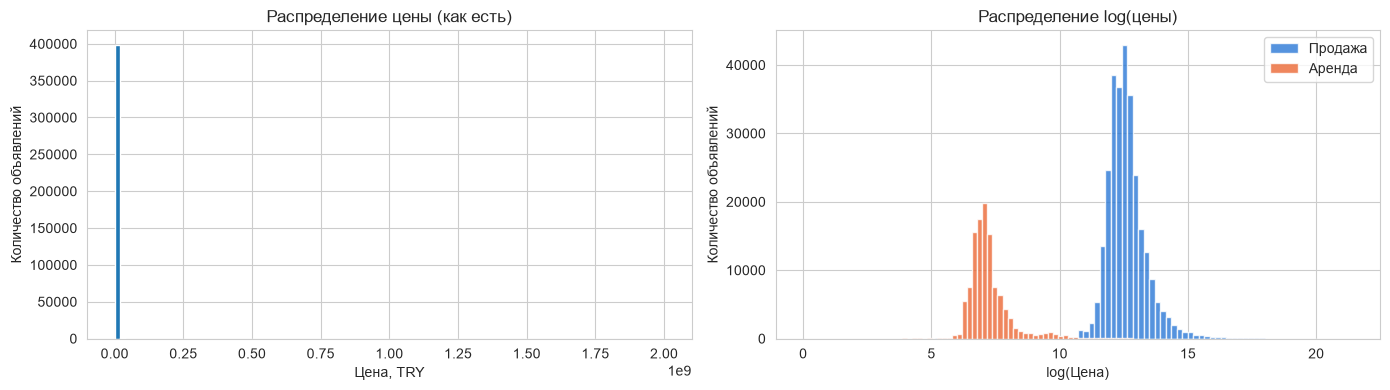

In [13]:
# у части объявлений цена указана как 0 - логарифм от нуля не существует,
# поэтому для графика берём только положительные цены (нули разберём в п. 1.4)
positive = df[df['price'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(positive['price'], bins=100)
axes[0].set_title('Распределение цены (как есть)')
axes[0].set_xlabel('Цена, TRY')
axes[0].set_ylabel('Количество объявлений')

for listing_type, name, color in [(1, 'Продажа', '#2a78d6'), (2, 'Аренда', '#eb6834')]:
    part = positive[positive['listing_type'] == listing_type]['price']
    axes[1].hist(np.log(part), bins=100, color=color, alpha=0.8, label=name)
axes[1].set_title('Распределение log(цены)')
axes[1].set_xlabel('log(Цена)')
axes[1].set_ylabel('Количество объявлений')
axes[1].legend()

plt.tight_layout()
plt.show()

Слева виден один столбик у нуля: все обычные объекты слиплись в одну полоску,
потому что шкалу растягивают единичные объекты за миллиард лир.
После логарифмирования (справа) видны два отдельных «горба» — аренда и продажа.
Внутри каждого из них распределение почти нормальное: логарифм цены брать правильно,
а тип объявления — самый важный признак для модели.

### График 2. Гистограммы основных числовых признаков

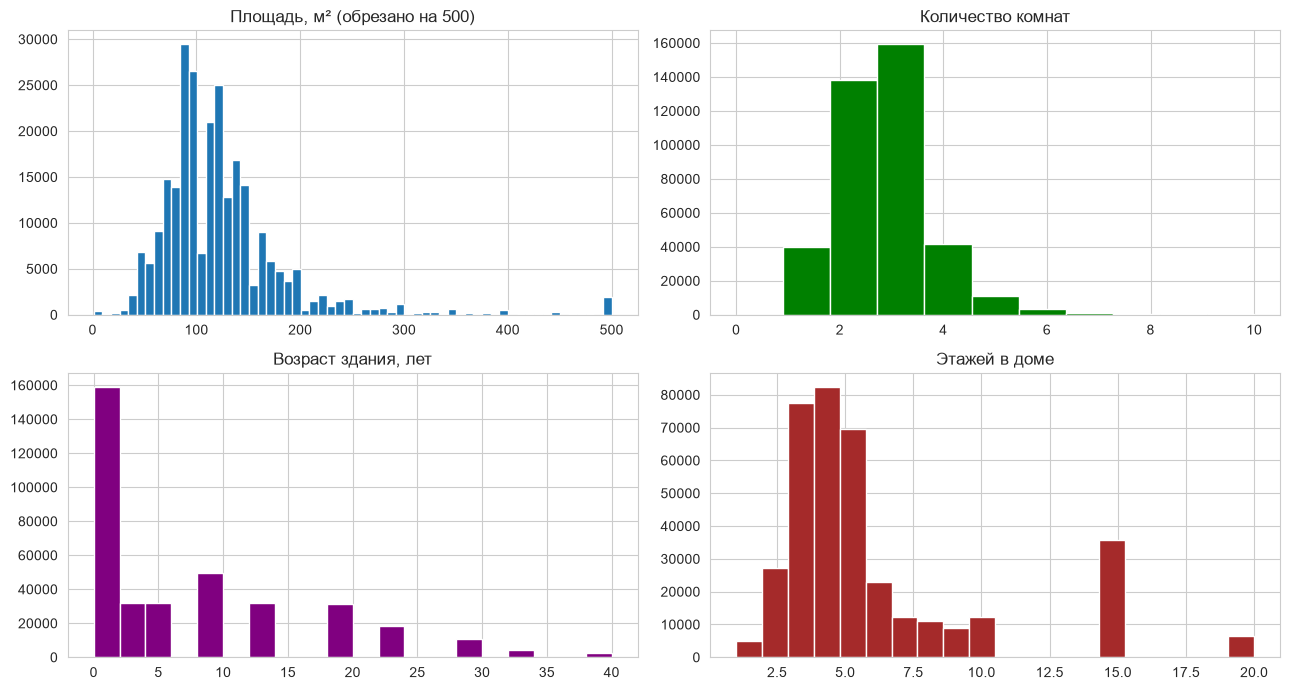

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

axes[0, 0].hist(df['size'].clip(0, 500), bins=60)
axes[0, 0].set_title('Площадь, м² (обрезано на 500)')

axes[0, 1].hist(df['rooms'].dropna().clip(0, 10), bins=11, color='green')
axes[0, 1].set_title('Количество комнат')

axes[1, 0].hist(df['building_age_num'].dropna(), bins=20, color='purple')
axes[1, 0].set_title('Возраст здания, лет')

axes[1, 1].hist(df['total_floors'].dropna(), bins=20, color='brown')
axes[1, 1].set_title('Этажей в доме')

plt.tight_layout()
plt.show()

Видно, что большинство квартир имеет площадь 80–140 м² и 2–3 комнаты,
а самая частая категория по возрасту здания — новостройки (возраст 0).

### График 3. Диаграмма рассеяния «площадь — цена»

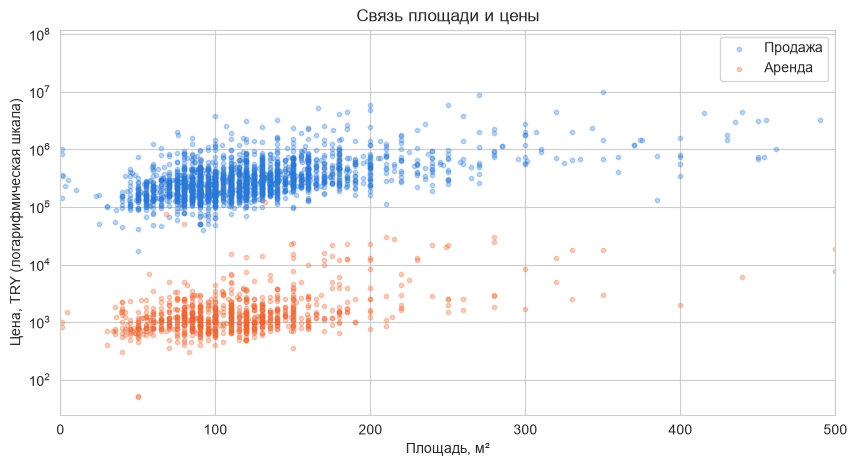

In [15]:
# берём случайные 5000 точек, иначе график превращается в чёрное пятно
sample = df[df['price'] > 0].sample(5000, random_state=RANDOM_STATE)

for listing_type, name, color in [(1, 'Продажа', '#2a78d6'), (2, 'Аренда', '#eb6834')]:
    part = sample[sample['listing_type'] == listing_type]
    plt.scatter(part['size'], part['price'], alpha=0.3, s=10, color=color, label=name)
plt.xlim(0, 500)
plt.yscale('log')
plt.xlabel('Площадь, м²')
plt.ylabel('Цена, TRY (логарифмическая шкала)')
plt.title('Связь площади и цены')
plt.legend()
plt.show()

Продажа и аренда образуют два облака, разнесённых по высоте в сотни раз.
Внутри каждого облака наклон положительный: чем больше площадь, тем выше цена.
Но разброс очень большой — при одной и той же площади цена отличается в разы.
Значит, кроме площади важны и другие признаки, в первую очередь расположение.

### График 4. Boxplot: цена по количеству комнат

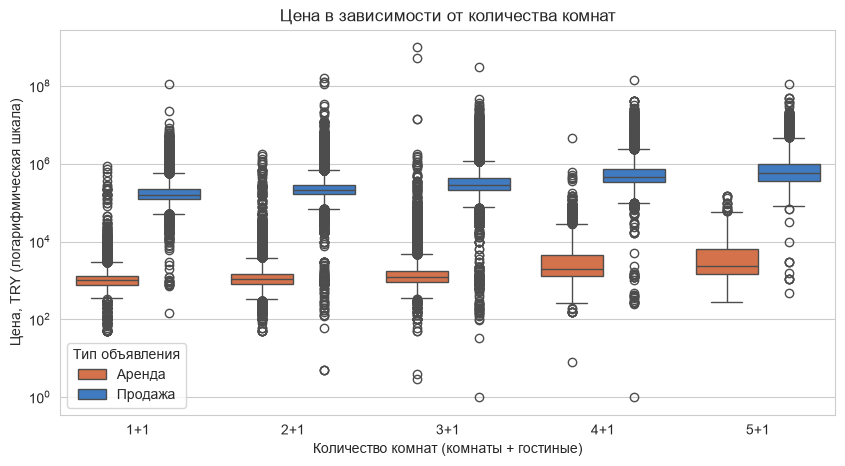

In [16]:
popular_rooms = ['1+1', '2+1', '3+1', '4+1', '5+1']
sub = df[df['room_count'].isin(popular_rooms) & (df['price'] > 0)].copy()
sub['Тип объявления'] = sub['listing_type'].map({1: 'Продажа', 2: 'Аренда'})

sns.boxplot(data=sub, x='room_count', y='price', hue='Тип объявления',
            order=popular_rooms, log_scale=True,
            palette={'Продажа': '#2a78d6', 'Аренда': '#eb6834'})
plt.xlabel('Количество комнат (комнаты + гостиные)')
plt.ylabel('Цена, TRY (логарифмическая шкала)')
plt.title('Цена в зависимости от количества комнат')
plt.show()

В обоих типах объявлений медиана цены растёт вместе с числом комнат, но «усы»
и выбросы у всех категорий перекрываются — одного этого признака для предсказания
цены недостаточно.

### График 5. Медианная цена продажи по городам

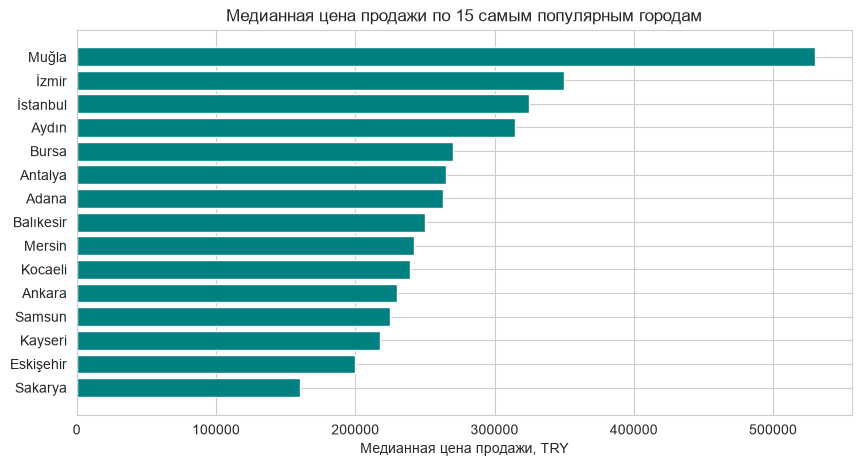

In [17]:
sale_df = df[df['listing_type'] == 1]

top15_cities = sale_df['city'].value_counts().head(15).index
city_price = (sale_df[sale_df['city'].isin(top15_cities)]
              .groupby('city')['price'].median().sort_values())

plt.barh(city_price.index, city_price.values, color='teal')
plt.xlabel('Медианная цена продажи, TRY')
plt.title('Медианная цена продажи по 15 самым популярным городам')
plt.show()

Разница между городами — в несколько раз. Это самый сильный аргумент за то,
чтобы обязательно включить расположение в модель.

### График 6. Тепловая карта корреляций

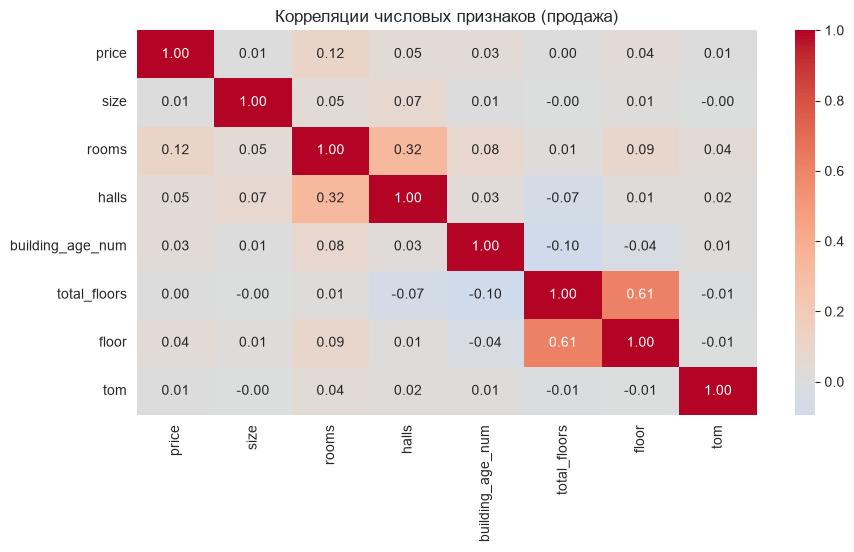

In [18]:
num_for_corr = ['price', 'size', 'rooms', 'halls', 'building_age_num',
                'total_floors', 'floor', 'tom']

# считаем по продаже: вместе с арендой корреляции с ценой показывали бы
# в первую очередь разницу между типами объявлений
corr = sale_df[num_for_corr].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Корреляции числовых признаков (продажа)')
plt.show()

## 1.4 Анализ пропусков и аномалий

### Пропуски

In [19]:
missing = pd.DataFrame({
    'Пропусков': df.isna().sum(),
    'Доля, %': (df.isna().mean() * 100).round(1)
})
missing = missing.sort_values('Доля, %', ascending=False)
missing

,Пропусков,"Доля, %"
furnished,398444,100.0
size,143446,36.0
end_date,134840,33.8
floor_no,34016,8.5
floor,34016,8.5
total_floors,27213,6.8
total_floor_count,27213,6.8
heating_type,27072,6.8
building_age,26455,6.6
building_age_num,26455,6.6


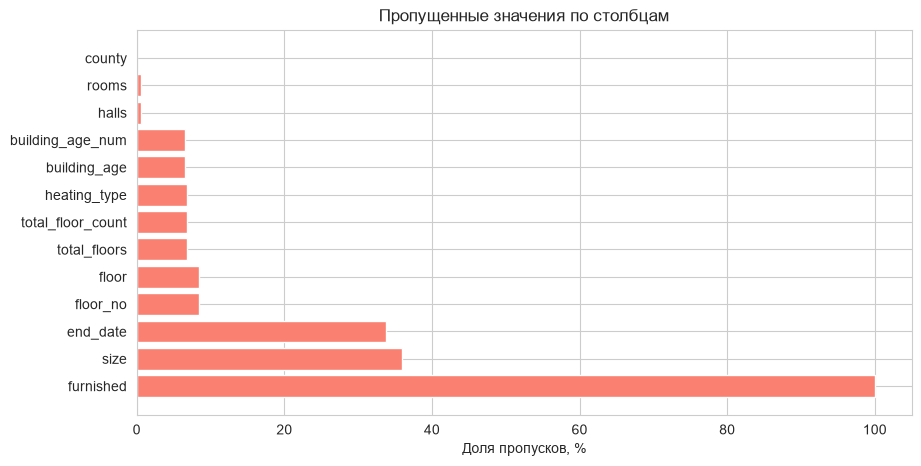

In [20]:
# оставляем только те столбцы, где пропуски действительно есть
to_plot = missing[missing['Пропусков'] > 0]

plt.barh(to_plot.index, to_plot['Доля, %'], color='salmon')
plt.xlabel('Доля пропусков, %')
plt.title('Пропущенные значения по столбцам')
plt.show()

### Дубликаты

In [21]:
cols_without_id = [c for c in df.columns if c != 'id']
print('Полных дубликатов (без учёта id):', df.duplicated(subset=cols_without_id).sum())

Полных дубликатов (без учёта id): 11109


### Логические проверки

In [22]:
is_sale = df['listing_type'] == 1

print('Цена <= 0:              ', (df['price'] <= 0).sum())
print('Площадь <= 0:           ', (df['size'] <= 0).sum())
print('Площадь меньше 20 м²:   ', (df['size'] < 20).sum())
print('Площадь больше 1000 м²: ', (df['size'] > 1000).sum())
print('Продажа дешевле 50 000: ', (is_sale & (df['price'] < 50_000)).sum())
print('Продажа дороже 10 млн:  ', (is_sale & (df['price'] > 10_000_000)).sum())
print('Аренда дешевле 300:     ', (~is_sale & (df['price'] < 300)).sum())
print('Аренда дороже 50 000:   ', (~is_sale & (df['price'] > 50_000)).sum())
print()
print('Максимальная площадь в данных:', df['size'].max(), 'м²')
print('Максимальная цена в данных:   ', df['price'].max(), 'TRY')

Цена <= 0:               45
Площадь <= 0:            0
Площадь меньше 20 м²:    480
Площадь больше 1000 м²:  587
Продажа дешевле 50 000:  1093
Продажа дороже 10 млн:   677
Аренда дешевле 300:      348
Аренда дороже 50 000:    458

Максимальная площадь в данных: 909039.0 м²
Максимальная цена в данных:    2000000000.0 TRY


Площадь почти в миллион квадратных метров и цена в 1 лиру — это явные ошибки
при заполнении объявления. Такие строки надо убрать.

## 1.5 Промежуточные выводы и гипотезы

**Что мы узнали о данных:**

1. В исходном файле 403 487 строк, в них смешаны продажа, аренда и посуточная аренда.
   После отбора продажи и аренды в лирах остаётся около 398 тысяч объявлений.
2. Столбец `furnished` пустой на 100% — его можно сразу удалить.
   Столбец `type` содержит одно значение — он тоже бесполезен.
3. `size` (площадь) пропущена примерно у трети объявлений. Это самый важный признак,
   поэтому строки без площади придётся удалить.
4. Цена распределена крайне несимметрично. После логарифмирования внутри каждого типа
   объявления распределение становится почти нормальным.
5. В данных есть заведомо нереальные значения: площадь в сотни тысяч м², цена в 1 лиру.

**Гипотезы о том, что влияет на цену:**

1. **Тип объявления — самый сильный фактор.** Месячная плата за аренду в сотни раз
   меньше цены продажи, поэтому без признака `listing_type` модель работать не сможет.
2. **Площадь — главный числовой фактор.** На диаграмме рассеяния видна явная
   положительная связь, а корреляция с ценой — самая высокая среди числовых признаков.
3. **Расположение важнее характеристик самой квартиры.** Медианные цены по городам
   отличаются в несколько раз, поэтому город и район обязательно нужно включить в модель.
4. **Количество комнат повышает цену**, но во многом это та же площадь, просто
   выраженная по-другому: на boxplot медиана растёт вместе с числом комнат.
5. **Возраст здания снижает цену:** у новостроек (возраст 0) цены заметно выше.
6. **Связь между признаками и ценой нелинейная.** Сами по себе корреляции невысокие,
   значит простая линейная регрессия справится плохо, а деревья и ансамбли — лучше.

---
# Этап 2. Предварительная обработка данных

Сначала создаём признаки и делим данные на train/validation/test, и только после этого
обучаем заполнение пропусков, кодировщик и скейлер — **строго на train**. Если посчитать
медианы или средние по всему датасету, информация из теста «протечёт» в обучение,
и оценка качества получится завышенной.

## 2.1 Работа с пропусками

Стратегия для каждого столбца своя:

| Столбец | Пропусков | Что делаем | Почему |
|---|---|---|---|
| `price` | мало | удаляем строки | это целевая переменная, её нельзя выдумать |
| `size` | ~35% | удаляем строки | самый важный признак, заполнение медианой испортит его |
| `furnished` | 100% | удаляем столбец | данных нет вообще |
| `end_date` | ~35% | удаляем столбец | неизвестна в момент публикации объявления |
| `building_age`, `total_floor_count`, `floor_no` | 7-9% | заполняем медианой по train | пропусков мало |
| `heating_type` | ~7% | отдельная категория «Нет данных» | сам факт «не указано» тоже информация |

In [23]:
print('Было строк:', len(df))

df = df.dropna(subset=['price', 'size'])

print('Стало строк:', len(df))

Было строк: 398444
Стало строк: 254998


## 2.2 Обработка выбросов

Используем **винсоризацию по здравому смыслу**: убираем строки, которые физически
не могут быть правдой. Границы выбраны по перцентилям, для продажи и аренды — свои:

* цена продажи от 50 000 до 10 000 000 лир,
* аренда от 300 до 50 000 лир в месяц,
* площадь от 20 до 1000 м².

Плюс удаляем полные дубликаты объявлений.

In [24]:
before = len(df)

is_sale = df['listing_type'] == 1
price_ok = np.where(is_sale,
                    df['price'].between(50_000, 10_000_000),
                    df['price'].between(300, 50_000))
df = df[price_ok]
df = df[(df['size'] >= 20) & (df['size'] <= 1000)]
df = df.drop_duplicates(subset=cols_without_id)

print('Удалено строк:', before - len(df))
print('Это', round((before - len(df)) / before * 100, 2), '% данных')
print('Осталось строк:', len(df))
print(df['listing_type'].map({1: 'продажа', 2: 'аренда'}).value_counts())

Удалено строк: 9587
Это 3.76 % данных
Осталось строк: 245411
listing_type
продажа    176813
аренда      68598
Name: count, dtype: int64


Потеряли около 4% строк.

Теперь логарифмируем целевую переменную. Модель будет учиться предсказывать `log(price)`,
а при выводе результата мы вернёмся к лирам через `np.exp()`.

In [25]:
df['log_price'] = np.log(df['price'])

print('Асимметрия цены до логарифма: ', round(df['price'].skew(), 2))
print('Асимметрия цены после логарифма:', round(df['log_price'].skew(), 2))

Асимметрия цены до логарифма:  7.63
Асимметрия цены после логарифма: -0.84


## 2.3 Feature Engineering — создаём новые признаки

In [26]:
# возраст здания уже посчитан в building_age_num, добавим флаг новостройки
df['is_new'] = (df['building_age_num'] == 0).astype(int)

# общее число помещений
df['total_rooms'] = df['rooms'] + df['halls']

# на каком этаже относительно высоты дома (0 = первый, 1 = последний)
df['floor_ratio'] = df['floor'] / df['total_floors']

# средняя площадь одной комнаты
df['size_per_room'] = df['size'] / df['total_rooms']

# деление могло дать бесконечность (если этажей или комнат было 0)
df = df.replace([np.inf, -np.inf], np.nan)

df[['is_new', 'total_rooms', 'floor_ratio', 'size_per_room']].describe()

,is_new,total_rooms,floor_ratio,size_per_room
count,245411.000000,244445.000000,226322.000000,244444.000000
mean,0.357930,3.679969,0.468288,32.665351
std,0.479392,1.102438,0.485198,11.136627
min,0.000000,0.000000,-4.000000,3.125000
25%,0.000000,3.000000,0.200000,27.500000
50%,0.000000,4.000000,0.466667,31.250000
75%,1.000000,4.000000,0.750000,35.000000
max,1.000000,14.000000,20.000000,1000.000000


### Признак, который мы намеренно НЕ используем

Напрашивается признак «цена за м²» — он очень хорошо объясняет цену.
Но считается он как `price / size`, то есть содержит внутри себя саму целевую переменную.
Это классическая **утечка данных (data leakage)**: модель показала бы R² около 0.99,
а в реальном приложении оказалась бы бесполезной, потому что цену мы как раз и не знаем.

По той же причине не берём:

* `tom` (сколько дней объявление висело на сайте) и `end_date` — они становятся
  известны уже **после** публикации, а прогноз нужен в момент подачи объявления;
* `id` — просто порядковый номер;
* `start_date` — данные собраны за полгода, сезонности на таком отрезке не увидеть.

### Редкие города и районы

Городов 82, а районов больше 450. Если закодировать все, получится огромная разреженная
матрица, где у половины колонок будет по 5 объявлений. Поэтому оставляем самые частые,
а остальные складываем в категорию «Другой».

In [27]:
top_cities = df['city'].value_counts().head(30).index
top_counties = df['county'].value_counts().head(100).index

df['city'] = np.where(df['city'].isin(top_cities), df['city'], 'Другой')
df['county'] = np.where(df['county'].isin(top_counties), df['county'], 'Другой')

print('Городов после группировки: ', df['city'].nunique())
print('Районов после группировки: ', df['county'].nunique())

Городов после группировки:  31
Районов после группировки:  101


### Собираем итоговый набор признаков

In [28]:
num_features = ['listing_type', 'size', 'building_age_num', 'total_floors', 'floor',
                'rooms', 'halls', 'total_rooms', 'is_new',
                'floor_ratio', 'size_per_room']

cat_features = ['sub_type', 'heating_type', 'city', 'county']

X = df[num_features + cat_features].copy()
y = df['log_price'].copy()

print('Признаков всего:', X.shape[1])
print('Объектов:       ', X.shape[0])
X.head()

Признаков всего: 15
Объектов:        245411


,listing_type,size,building_age_num,total_floors,floor,rooms,halls,total_rooms,is_new,floor_ratio,size_per_room,sub_type,heating_type,city,county
0,2,90.0,0.0,20.0,2.0,2.0,1.0,3.0,1,0.100000,30.0,Rezidans,Fancoil,İstanbul,Kartal
1,1,43.0,0.0,20.0,20.0,1.0,0.0,1.0,1,1.000000,43.0,Daire,Fancoil,İstanbul,Kartal
4,1,90.0,0.0,20.0,2.0,2.0,1.0,3.0,1,0.100000,30.0,Rezidans,Fancoil,İstanbul,Kartal
5,1,45.0,2.0,15.0,10.0,1.0,1.0,2.0,0,0.666667,22.5,Rezidans,Fancoil,İstanbul,Maltepe
6,2,160.0,0.0,20.0,14.0,3.0,1.0,4.0,1,0.700000,40.0,Daire,Fancoil,İstanbul,Kartal


## 2.4 Проверка мультиколлинеарности

Если два признака почти повторяют друг друга, линейная модель начинает «сходить с ума»:
коэффициенты становятся огромными и нестабильными. Найдём пары с корреляцией выше 0.9.

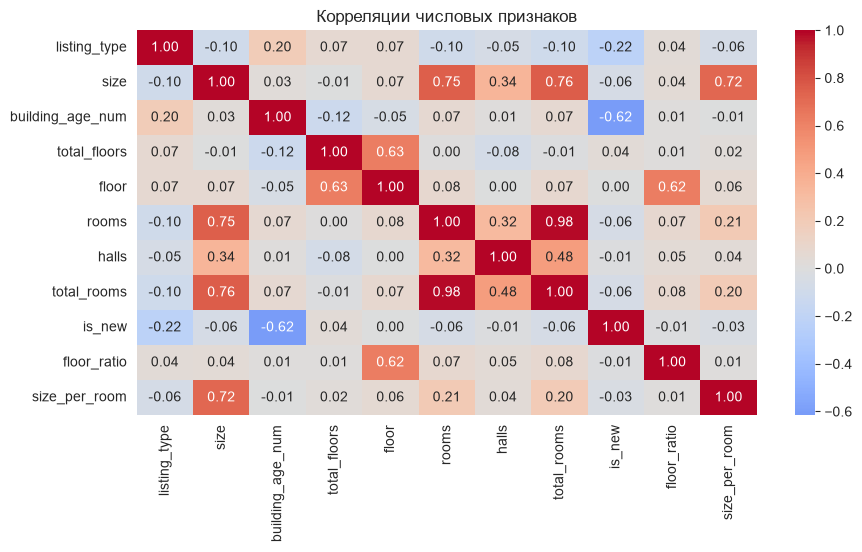

In [29]:
corr_matrix = X[num_features].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Корреляции числовых признаков')
plt.show()

In [30]:
# ищем пары сильно связанных признаков
to_drop = []

for i in range(len(num_features)):
    for j in range(i + 1, len(num_features)):
        a = num_features[i]
        b = num_features[j]
        c = corr_matrix.loc[a, b]
        if abs(c) > 0.9:
            print('Сильная связь:', a, '<->', b, ' корреляция =', round(c, 2))
            if b not in to_drop:
                to_drop.append(b)

print()
print('Удаляем признаки:', to_drop)

Сильная связь: rooms <-> total_rooms  корреляция = 0.98

Удаляем признаки: ['total_rooms']


In [31]:
if len(to_drop) > 0:
    X = X.drop(columns=to_drop)
    num_features = [c for c in num_features if c not in to_drop]

print('Осталось признаков:', X.shape[1])

Осталось признаков: 14


## 2.5 Разбиение данных на train / validation / test

Делим в пропорции **70 / 15 / 15**:

* **train** — на нём обучаются модели,
* **validation** — на нём сравниваем модели и выбираем лучшую,
* **test** — трогаем один раз в самом конце, чтобы получить честную оценку.

`random_state` фиксируем, чтобы разбиение повторялось при каждом запуске, а `stratify`
сохраняет одинаковую долю аренды во всех трёх частях.

In [32]:
from sklearn.model_selection import train_test_split

# сначала отделяем 70% на train
X_train, X_rest, y_train, y_rest = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=X['listing_type'])

# оставшиеся 30% делим пополам: 15% valid и 15% test
X_valid, X_test, y_valid, y_test = train_test_split(
    X_rest, y_rest, test_size=0.5, random_state=RANDOM_STATE,
    stratify=X_rest['listing_type'])

print('train:     ', X_train.shape)
print('validation:', X_valid.shape)
print('test:      ', X_test.shape)
print()
print('Доля аренды в train, valid, test:',
      [round(float((part['listing_type'] == 2).mean()), 3) for part in [X_train, X_valid, X_test]])

train:      (171787, 14)
validation: (36812, 14)
test:       (36812, 14)

Доля аренды в train, valid, test: [0.28, 0.28, 0.28]


## 2.6 Заполнение пропусков, кодирование и масштабирование

Все три преобразования настраиваются **только на train**, а к validation и test
применяются уже готовыми. Так мы гарантируем отсутствие утечки данных.

In [33]:
# числа заполняем медианой, посчитанной ТОЛЬКО по train, категории - значением 'Нет данных'
medians = X_train[num_features].median()

for part in [X_train, X_valid, X_test]:
    part[num_features] = part[num_features].fillna(medians)
    part[cat_features] = part[cat_features].fillna('Нет данных')

print('Пропусков в train:', X_train.isna().sum().sum())
print('Пропусков в valid:', X_valid.isna().sum().sum())
print('Пропусков в test: ', X_test.isna().sum().sum())

Пропусков в train: 0
Пропусков в valid: 0
Пропусков в test:  0


### One-Hot Encoding категориальных признаков

Все наши категории номинальные (город, тип дома, отопление) — порядка между ними нет,
поэтому используем именно One-Hot, а не порядковое кодирование.

Список колонок берём из train: категория, которой не было в обучении, получит нули.

In [34]:
X_train = pd.get_dummies(X_train, columns=cat_features, dtype=int)

X_valid = pd.get_dummies(X_valid, columns=cat_features, dtype=int)
X_valid = X_valid.reindex(columns=X_train.columns, fill_value=0)

X_test = pd.get_dummies(X_test, columns=cat_features, dtype=int)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print('Признаков после кодирования:', X_train.shape[1])
X_train.head()

Признаков после кодирования: 171


,listing_type,size,building_age_num,total_floors,floor,rooms,halls,is_new,floor_ratio,size_per_room,...,county_Çınarcık,county_Ümraniye,county_Üsküdar,county_İlkadım,county_İzmit,county_Şahinbey,county_Şehitkamil,county_Şehzadeler,county_Şişli,county_Другой
197524,1,115.0,0.0,5.0,3.0,3.0,1.0,1,0.600000,28.75,...,0,0,0,0,0,0,0,0,0,1
13777,1,125.0,3.0,4.0,0.0,3.0,1.0,0,0.000000,31.25,...,0,0,0,0,0,0,0,0,0,1
180288,1,140.0,8.0,5.0,1.0,3.0,1.0,0,0.200000,35.00,...,0,0,0,0,0,0,0,1,0,0
66079,1,150.0,13.0,5.0,-2.0,3.0,1.0,0,-0.400000,37.50,...,0,0,0,0,0,0,0,0,0,0
267484,2,120.0,13.0,3.0,2.0,3.0,1.0,0,0.666667,30.00,...,0,0,0,0,0,0,0,0,0,0


### Масштабирование

`StandardScaler` обязателен для линейной модели (Ridge): без него признак «площадь»
со значениями в сотнях перевесит бинарные признаки из нулей и единиц.
Деревьям и ансамблям масштабирование не нужно — им важен только порядок значений,
а не их величина. Поэтому мы готовим **обе версии** данных.

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)   # обучаем только на train

# оборачиваем обратно в DataFrame, чтобы не потерять названия колонок
X_train_sc = pd.DataFrame(scaler.transform(X_train),
                          columns=X_train.columns, index=X_train.index)
X_valid_sc = pd.DataFrame(scaler.transform(X_valid),
                          columns=X_valid.columns, index=X_valid.index)
X_test_sc = pd.DataFrame(scaler.transform(X_test),
                         columns=X_test.columns, index=X_test.index)

print('Данные готовы к обучению')

Данные готовы к обучению


---
# Этап 3. Построение моделей регрессии

## 3.1 Какие модели берём и почему

Берём модели **разной природы**, чтобы сравнение было честным:

| Модель | Тип | Идея |
|---|---|---|
| `Ridge` | линейная | проводит через данные прямую, штрафуя большие коэффициенты |
| `DecisionTreeRegressor` | одно дерево | режет данные на прямоугольники по принципу «если... то...» |
| `RandomForestRegressor` | **ансамбль, бэггинг** | много деревьев на случайных подвыборках, ответы усредняются |
| `GradientBoostingRegressor` | **ансамбль, бустинг** | деревья строятся по очереди, каждое исправляет ошибки предыдущих |
| `HistGradientBoostingRegressor` | **ансамбль, бустинг** | быстрая современная реализация бустинга (как LightGBM) |
| `StackingRegressor` | **ансамбль, стекинг** | мета-модель учится комбинировать ответы всех остальных |

Ridge и одиночное дерево — это «слабые ученики». Ансамбли собирают из них «сильного ученика»:

* **бэггинг** (случайный лес) снижает **разброс (variance)** — деревья ошибаются
  независимо, и при усреднении ошибки гасят друг друга;
* **бустинг** снижает **смещение (bias)** — каждая следующая модель учится на ошибках предыдущей;
* **стекинг** позволяет использовать сильные стороны сразу всех алгоритмов.

In [36]:
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              HistGradientBoostingRegressor, StackingRegressor)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

print('Модели импортированы')

Модели импортированы


### Функция для расчёта метрик

Считаем 4 метрики. Важный момент: модель предсказывает **логарифм** цены, а метрики
нужно считать в **лирах** — иначе MAE будет измеряться в непонятных единицах.
Поэтому перед расчётом возвращаемся из логарифма через `np.exp()`.

* **MAE** — на сколько лир в среднем ошибаемся;
* **RMSE** — то же самое, но крупные ошибки штрафуются сильнее;
* **MAPE** — средняя ошибка в процентах, самая понятная для заказчика метрика;
* **R²** — какую долю разброса цен модель сумела объяснить (1.0 — идеал, 0 — уровень «всегда предсказываю среднее»).

Цены продажи в сотни раз больше арендных, поэтому MAE, RMSE и R² в лирах по всей выборке
определяются в основном продажей, а MAPE одинаково учитывает оба типа. Для финальной модели
метрики посчитаем ещё и отдельно для продажи и аренды.

In [37]:
def get_metrics(model_name, y_true_log, y_pred_log):
    # возвращаемся из логарифма в лиры
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    return {'Модель': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE, %': mape, 'R2': r2}


print('Функция метрик готова')

Функция метрик готова


## 3.2 Обучение моделей. Шаг 1 — базовые версии

Сначала смотрим, что дают модели «из коробки». Это точка отсчёта, с которой будем
сравнивать результат подбора гиперпараметров.

In [38]:
base_results = []

base_models = {
    'Ridge (базовая)': Ridge(),
    'Дерево решений (базовая)': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Случайный лес (базовая)': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'Градиентный бустинг (базовая)': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'Hist бустинг (базовая)': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}

for name, model in base_models.items():
    start = time.time()

    # линейной модели нужны масштабированные данные, остальным - всё равно
    if name.startswith('Ridge'):
        model.fit(X_train_sc, y_train)
        pred = model.predict(X_valid_sc)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_valid)

    row = get_metrics(name, y_valid, pred)
    row['Время обучения, с'] = round(time.time() - start, 1)
    base_results.append(row)

    print(name, '- готово за', row['Время обучения, с'], 'с')

base_table = pd.DataFrame(base_results).set_index('Модель').round(2)
base_table

Ridge (базовая) - готово за 0.3 с


Дерево решений (базовая) - готово за 3.6 с


Случайный лес (базовая) - готово за 62.4 с


Градиентный бустинг (базовая) - готово за 48.8 с


Hist бустинг (базовая) - готово за 5.6 с


,MAE,RMSE,"MAPE, %",R2,"Время обучения, с"
Модель,,,,,
Ridge (базовая),101938.94,363464.67,30.65,0.54,0.3
Дерево решений (базовая),81766.40,339281.60,27.98,0.60,3.6
Случайный лес (базовая),68251.89,267000.01,21.17,0.75,62.4
Градиентный бустинг (базовая),105115.63,357344.15,32.74,0.56,48.8
Hist бустинг (базовая),89760.16,307133.07,27.41,0.67,5.6


Уже на базовых настройках с большим отрывом лидирует **случайный лес**: MAPE около 21%
против 27–33% у остальных. Бустингу с настройками по умолчанию (100 неглубоких деревьев)
не хватает сложности — его нужно настраивать. Одиночное дерево без ограничения глубины
переобучается: запоминает обучающую выборку и хуже работает на новых данных.

## 3.2 Обучение моделей. Шаг 2 — подбор гиперпараметров с кросс-валидацией

Перебор параметров на всех 170 тысячах строк занял бы очень много времени,
поэтому подбираем на случайной подвыборке из train (30 000 строк), а лучшие найденные
параметры потом применяем ко **всему** train.

Важно: подбор идёт по кросс-валидации **внутри train**. Валидационную и тестовую выборки
мы на этом шаге не трогаем совсем — иначе результат был бы завышенным.

In [39]:
# подвыборка для ускорения перебора
X_small = X_train.sample(30_000, random_state=RANDOM_STATE)
y_small = y_train.loc[X_small.index]
X_small_sc = X_train_sc.loc[X_small.index]

print('Размер подвыборки для подбора:', X_small.shape)

Размер подвыборки для подбора: (30000, 171)


### Ridge — перебираем силу регуляризации

In [40]:
grid_ridge = {'alpha': [0.1, 1, 10, 100, 500]}

search_ridge = GridSearchCV(Ridge(), grid_ridge, cv=3,
                            scoring='neg_mean_absolute_error', n_jobs=-1)
search_ridge.fit(X_train_sc, y_train)   # Ridge быстрая, можно на всём train

print('Лучшие параметры:', search_ridge.best_params_)
best_ridge = search_ridge.best_estimator_

Лучшие параметры: {'alpha': 0.1}


### Дерево решений — ограничиваем глубину, чтобы не переобучалось

In [41]:
grid_tree = {
    'max_depth': [8, 12, 16, 20],
    'min_samples_leaf': [1, 5, 20],
}

search_tree = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE),
                           grid_tree, cv=3,
                           scoring='neg_mean_absolute_error', n_jobs=-1)
search_tree.fit(X_small, y_small)

print('Лучшие параметры:', search_tree.best_params_)
best_tree = DecisionTreeRegressor(random_state=RANDOM_STATE, **search_tree.best_params_)
best_tree.fit(X_train, y_train)

Лучшие параметры: {'max_depth': 16, 'min_samples_leaf': 5}


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",16
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with `

### Случайный лес (бэггинг)

Здесь параметров много, полный перебор был бы долгим, поэтому берём
`RandomizedSearchCV` — он проверяет случайные комбинации, а не все подряд.

In [42]:
grid_forest = {
    'n_estimators': [100, 200],
    'max_depth': [12, 20, None],
    'min_samples_leaf': [1, 3, 10],
    'max_features': ['sqrt', 0.5],
}

search_forest = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    grid_forest, n_iter=6, cv=3,
    scoring='neg_mean_absolute_error', random_state=RANDOM_STATE)
search_forest.fit(X_small, y_small)

print('Лучшие параметры:', search_forest.best_params_)

best_forest = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1,
                                    **search_forest.best_params_)
best_forest.fit(X_train, y_train)
print('Лес обучен на полном train')

Лучшие параметры: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}


Лес обучен на полном train


### Градиентный бустинг (классическая реализация)

In [43]:
grid_boost = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
}

search_boost = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    grid_boost, n_iter=4, cv=3,
    scoring='neg_mean_absolute_error', random_state=RANDOM_STATE, n_jobs=-1)
search_boost.fit(X_small, y_small)

print('Лучшие параметры:', search_boost.best_params_)

best_boost = GradientBoostingRegressor(random_state=RANDOM_STATE, **search_boost.best_params_)
best_boost.fit(X_train, y_train)
print('Бустинг обучен на полном train')

Лучшие параметры: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}


Бустинг обучен на полном train


### Hist-бустинг (быстрая современная реализация)

`HistGradientBoostingRegressor` — это та же идея бустинга, но с гистограммным
разбиением признаков. Работает в десятки раз быстрее обычного `GradientBoostingRegressor`
и обычно даёт качество не хуже. Именно так устроены LightGBM и CatBoost.

In [44]:
grid_hist = {
    'max_iter': [200, 400],
    'max_depth': [6, 10, None],
    'learning_rate': [0.05, 0.1],
    'min_samples_leaf': [20, 50],
}

search_hist = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    grid_hist, n_iter=8, cv=3,
    scoring='neg_mean_absolute_error', random_state=RANDOM_STATE, n_jobs=-1)
search_hist.fit(X_small, y_small)

print('Лучшие параметры:', search_hist.best_params_)

best_hist = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **search_hist.best_params_)
best_hist.fit(X_train, y_train)
print('Hist-бустинг обучен на полном train')

Лучшие параметры: {'min_samples_leaf': 20, 'max_iter': 400, 'max_depth': 10, 'learning_rate': 0.1}


Hist-бустинг обучен на полном train


### Стекинг — объединяем всё вместе

Мета-модель (обычная линейная регрессия) получает на вход предсказания четырёх базовых
моделей и учится решать, кому в какой ситуации доверять больше.
`cv=3` означает, что предсказания для мета-модели берутся с кросс-валидации —
так базовая модель не «подглядывает» в те строки, на которых училась.

Подаём всем моделям масштабированные данные: линейной модели это необходимо,
а деревьям безразлично, потому что масштабирование не меняет порядок значений.

In [45]:
stack = StackingRegressor(
    estimators=[
        ('ridge', best_ridge),
        ('tree', best_tree),
        ('forest', best_forest),
        ('hist', best_hist),
    ],
    final_estimator=LinearRegression(),
    cv=3,
    n_jobs=-1,
)

start = time.time()
stack.fit(X_train_sc, y_train)
print('Стекинг обучен за', round(time.time() - start, 1), 'с')

Стекинг обучен за 386.6 с


## 3.3 Сравнение моделей

Считаем метрики всех настроенных моделей на **валидационной** выборке.

In [46]:
tuned_results = []

tuned_models = {
    'Ridge': (best_ridge, True),
    'Дерево решений': (best_tree, False),
    'Случайный лес (бэггинг)': (best_forest, False),
    'Градиентный бустинг': (best_boost, False),
    'Hist-бустинг': (best_hist, False),
    'Стекинг': (stack, True),
}

for name, (model, need_scaling) in tuned_models.items():
    if need_scaling:
        pred = model.predict(X_valid_sc)
    else:
        pred = model.predict(X_valid)
    tuned_results.append(get_metrics(name, y_valid, pred))

results_table = pd.DataFrame(tuned_results).set_index('Модель').round(2)
results_table.sort_values('MAE')

,MAE,RMSE,"MAPE, %",R2
Модель,,,,
Случайный лес (бэггинг),67358.92,269089.41,20.57,0.75
Стекинг,69797.15,266220.78,21.08,0.75
Hist-бустинг,82688.98,279616.59,25.31,0.73
Градиентный бустинг,89432.50,298749.38,27.57,0.69
Дерево решений,91945.79,304335.66,29.92,0.68
Ridge,101939.16,363465.82,30.65,0.54


### График сравнения моделей по метрикам

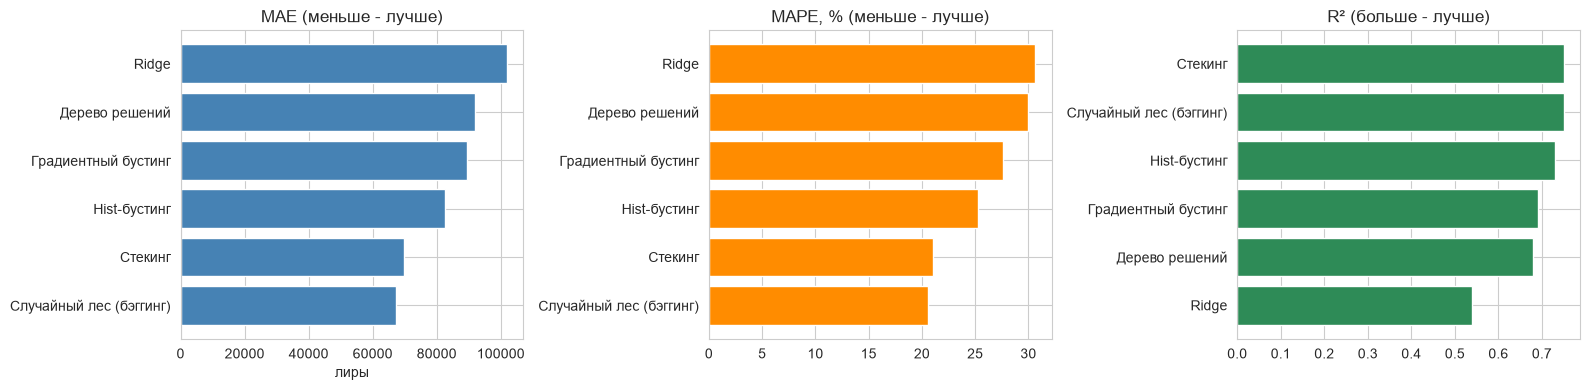

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sorted_mae = results_table['MAE'].sort_values()
axes[0].barh(sorted_mae.index, sorted_mae.values, color='steelblue')
axes[0].set_title('MAE (меньше - лучше)')
axes[0].set_xlabel('лиры')

sorted_mape = results_table['MAPE, %'].sort_values()
axes[1].barh(sorted_mape.index, sorted_mape.values, color='darkorange')
axes[1].set_title('MAPE, % (меньше - лучше)')

sorted_r2 = results_table['R2'].sort_values()
axes[2].barh(sorted_r2.index, sorted_r2.values, color='seagreen')
axes[2].set_title('R² (больше - лучше)')

plt.tight_layout()
plt.show()

In [48]:
# выбираем лучшую модель по MAE
best_name = results_table['MAE'].idxmin()
best_model, best_needs_scaling = tuned_models[best_name]

print('Лучшая модель по метрикам:', best_name)

Лучшая модель по метрикам: Случайный лес (бэггинг)


### График «предсказание против факта» для лучшей модели

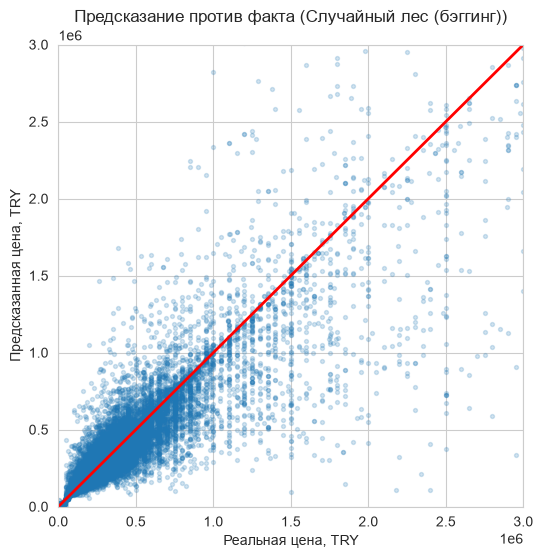

In [49]:
if best_needs_scaling:
    pred_valid = best_model.predict(X_valid_sc)
else:
    pred_valid = best_model.predict(X_valid)

# возвращаемся в лиры
fact = np.exp(y_valid)
pred = np.exp(pred_valid)

plt.figure(figsize=(6, 6))
plt.scatter(fact, pred, alpha=0.2, s=8)
plt.plot([0, 3_000_000], [0, 3_000_000], color='red', linewidth=2)
plt.xlim(0, 3_000_000)
plt.ylim(0, 3_000_000)
plt.xlabel('Реальная цена, TRY')
plt.ylabel('Предсказанная цена, TRY')
plt.title('Предсказание против факта (' + best_name + ')')
plt.show()

Красная линия — идеальный прогноз. Точки лежат вдоль неё, значит модель работает.
Заметно, что для дорогих объектов разброс больше: таких объявлений в данных мало,
и модель их предсказывает хуже.

### График остатков

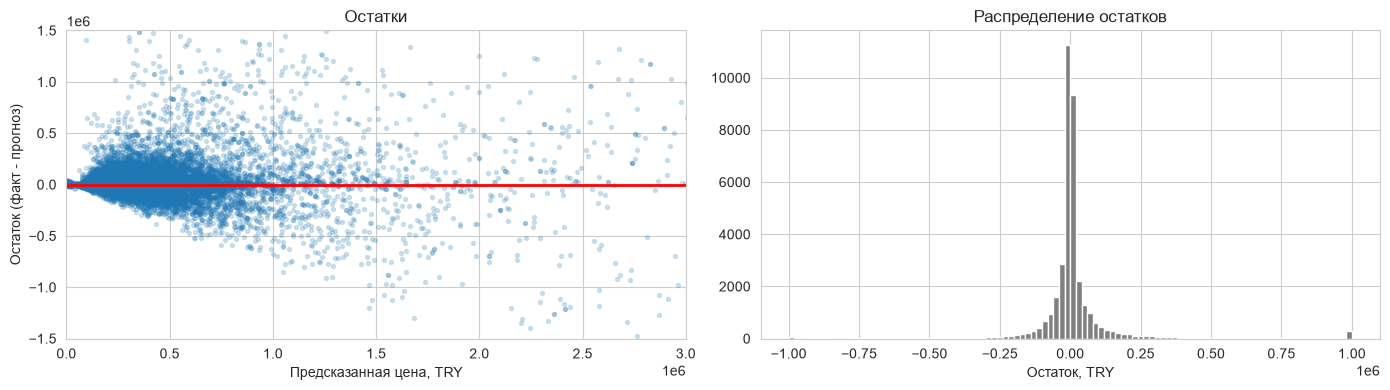

In [50]:
residuals = fact - pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(pred, residuals, alpha=0.2, s=8)
axes[0].axhline(0, color='red', linewidth=2)
axes[0].set_xlim(0, 3_000_000)
axes[0].set_ylim(-1_500_000, 1_500_000)
axes[0].set_xlabel('Предсказанная цена, TRY')
axes[0].set_ylabel('Остаток (факт - прогноз)')
axes[0].set_title('Остатки')

axes[1].hist(residuals.clip(-1_000_000, 1_000_000), bins=100, color='grey')
axes[1].set_title('Распределение остатков')
axes[1].set_xlabel('Остаток, TRY')

plt.tight_layout()
plt.show()

### Важность признаков

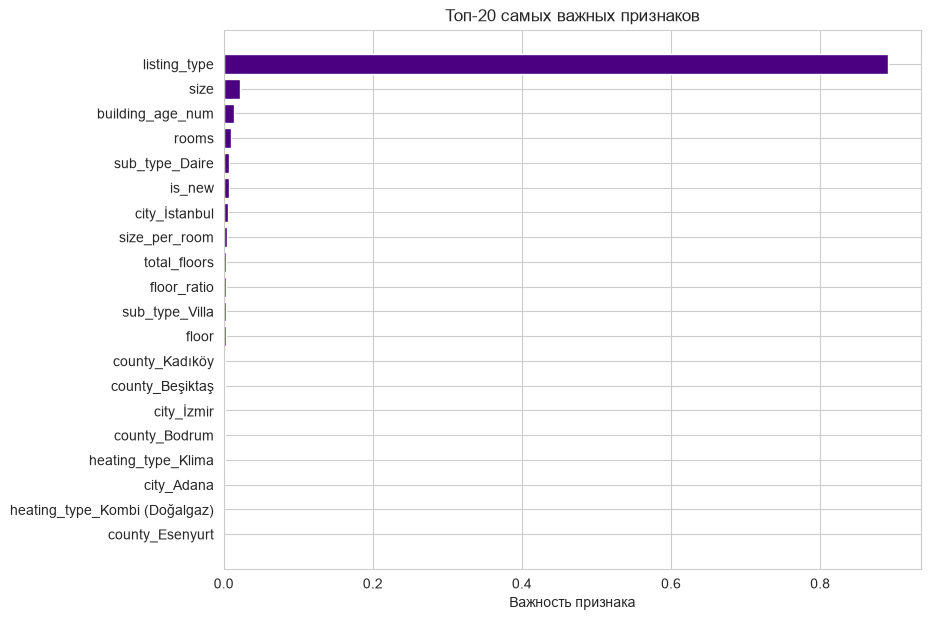

In [51]:
# у деревьев и ансамблей есть feature_importances_
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
else:
    # у стекинга берём важности из случайного леса внутри него
    importances = pd.Series(best_forest.feature_importances_, index=X_train.columns)

top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 7))
plt.barh(top20.index[::-1], top20.values[::-1], color='indigo')
plt.xlabel('Важность признака')
plt.title('Топ-20 самых важных признаков')
plt.show()

In [52]:
# для сравнения посмотрим на коэффициенты линейной модели
coefs = pd.Series(best_ridge.coef_, index=X_train.columns)
print('Самые сильные положительные коэффициенты Ridge:')
print(coefs.sort_values(ascending=False).head(8).round(3))
print()
print('Самые сильные отрицательные коэффициенты Ridge:')
print(coefs.sort_values().head(8).round(3))

Самые сильные положительные коэффициенты Ridge:
city_İstanbul      0.208
rooms              0.184
size               0.164
county_Beşiktaş    0.096
county_Kuşadası    0.081
county_Didim       0.080
county_Bodrum      0.079
city_İzmir         0.077
dtype: float64

Самые сильные отрицательные коэффициенты Ridge:
listing_type        -2.413
county_Esenyurt     -0.116
city_Aydın          -0.104
county_Beylikdüzü   -0.078
city_Ankara         -0.070
sub_type_Daire      -0.067
city_Samsun         -0.065
city_Другой         -0.062
dtype: float64


## 3.4 Выбор финальной модели

По метрикам впереди две модели — случайный лес и стекинг, и разница между ними
небольшая. Но для приложения метрики не единственный критерий. Посмотрим ещё на
три практические вещи: **размер файла модели**, **скорость предсказания** и
**интерпретируемость**.

In [53]:
import os

def model_size_mb(model):
    # сохраняем модель во временный файл и смотрим, сколько она весит
    joblib.dump(model, 'tmp_size_check.pkl')
    size = os.path.getsize('tmp_size_check.pkl') / 1024 / 1024
    os.remove('tmp_size_check.pkl')
    return size


practical = []

for name, (model, need_scaling) in tuned_models.items():
    data = X_valid_sc if need_scaling else X_valid

    start = time.time()
    model.predict(data)
    predict_time = time.time() - start

    practical.append({
        'Модель': name,
        'MAE': round(results_table.loc[name, 'MAE']),
        'MAPE, %': results_table.loc[name, 'MAPE, %'],
        'Размер файла, МБ': round(model_size_mb(model)),
        'Прогноз 26 тыс. строк, с': round(predict_time, 2),
    })

pd.DataFrame(practical).set_index('Модель')

,MAE,"MAPE, %","Размер файла, МБ","Прогноз 26 тыс. строк, с"
Модель,,,,
Ridge,101939,30.65,0,0.01
Дерево решений,91946,29.92,1,0.05
Случайный лес (бэггинг),67359,20.57,2240,0.71
Градиентный бустинг,89432,27.57,1,0.84
Hist-бустинг,82689,25.31,1,0.17
Стекинг,69797,21.08,4484,0.89


Вот здесь и вылезает проблема. Случайный лес весит больше двух гигабайт,
а стекинг — ещё вдвое больше, потому что внутри него лежит копия этого же леса.
Такой файл неудобно хранить и долго загружать в приложении.

Причина размера — параметр `min_samples_leaf=1`, который выбрал случайный поиск:
при нём деревья растут до упора, пока в каждом листе не останется по одному объекту.
На 172 тысячах строк получается 200 огромных деревьев.

Уменьшить лес можно двумя способами, и важно понять, какой из них дешевле:

1. **срезать число деревьев** (`n_estimators`),
2. **огрубить сами деревья** (`min_samples_leaf`).

Проверим оба.

In [54]:
compare = []

for n_trees, leaf in [(200, 1), (50, 1), (30, 1), (15, 1), (200, 5)]:
    forest = RandomForestRegressor(
        n_estimators=n_trees, max_features=0.5, min_samples_leaf=leaf,
        random_state=RANDOM_STATE, n_jobs=-1)
    forest.fit(X_train, y_train)

    name = str(n_trees) + ' деревьев, min_samples_leaf=' + str(leaf)
    row = get_metrics(name, y_valid, forest.predict(X_valid))
    row['Размер файла, МБ'] = round(model_size_mb(forest))
    compare.append(row)

    print(name, '- готово')

compare_table = pd.DataFrame(compare).set_index('Модель').round(2)
compare_table

200 деревьев, min_samples_leaf=1 - готово


50 деревьев, min_samples_leaf=1 - готово


30 деревьев, min_samples_leaf=1 - готово


15 деревьев, min_samples_leaf=1 - готово


200 деревьев, min_samples_leaf=5 - готово


,MAE,RMSE,"MAPE, %",R2,"Размер файла, МБ"
Модель,,,,,
"200 деревьев, min_samples_leaf=1",67358.92,269089.41,20.57,0.75,2240
"50 деревьев, min_samples_leaf=1",67744.76,268434.05,20.82,0.75,560
"30 деревьев, min_samples_leaf=1",68517.46,272450.58,20.99,0.74,336
"15 деревьев, min_samples_leaf=1",69525.63,276515.45,21.44,0.73,168
"200 деревьев, min_samples_leaf=5",78982.67,293936.00,23.43,0.70,422


Результат получился поучительный: **два способа уменьшить лес стоят совершенно разного**.

* Срезать число деревьев почти бесплатно. С 200 до 15 файл худеет в тринадцать раз,
  а MAPE ухудшается меньше чем на один процентный пункт.
* А вот огрубление деревьев обходится дорого: `min_samples_leaf=5` роняет MAPE
  почти на три пункта, и при этом файл получается даже **больше**, чем у леса из
  30 полных деревьев. То есть этот вариант проигрывает по обоим параметрам сразу.

Объяснение прямо следует из теории бэггинга. Каждое дерево в лесу — самостоятельный
эксперт, и ошибки у них независимые. Полутора-двух десятков экспертов уже достаточно,
чтобы усреднение сработало и погасило разброс — сотня почти ничего не добавляет.
А вот обрезка листьев портит каждое дерево по отдельности, и усреднять становится нечего:
такую ошибку бэггинг исправить не может, потому что она общая для всех деревьев.

### Итоговое обоснование выбора

Финальная модель — **случайный лес из 15 деревьев без обрезки листьев**:

* по MAPE он отличается от лучшего варианта меньше чем на один процентный
  пункт — при файле, который меньше в тринадцать раз;
* приложение работает в облаке с 1 ГБ оперативной памяти: лес из 200 деревьев
  (2.2 ГБ) туда не поместится, а лес из 15 деревьев весит 168 МБ;
* предсказание занимает доли секунды — форма прогноза ответит без задержки;
* у леса есть `feature_importances_`, то есть пользователю можно показать,
  какие признаки повлияли на цену. У стекинга такой возможности нет,
  а это важно для доверия к прогнозу.

Стекинг чуть лучше по R² и RMSE, но выигрыш в третьем знаке не стоит
многогигабайтного файла и потери интерпретируемости.

In [55]:
final_model = RandomForestRegressor(
    n_estimators=15, max_features=0.5, min_samples_leaf=1,
    random_state=RANDOM_STATE, n_jobs=-1)
final_model.fit(X_train, y_train)

final_name = 'Случайный лес (15 деревьев)'
print('Финальная модель обучена')

Финальная модель обучена


### Финальная проверка на тестовой выборке

Тестовую выборку мы до этого момента не трогали ни разу. Проверяем на ней
финальную модель — это и есть честная оценка того, как она поведёт себя
на новых данных.

In [56]:
pred_valid_final = final_model.predict(X_valid)
pred_test = final_model.predict(X_test)

final_metrics = get_metrics(final_name + ' (ТЕСТ)', y_test, pred_test)

final_rows = [
    get_metrics(final_name + ' (валидация)', y_valid, pred_valid_final),
    final_metrics,
]

# отдельно для продажи и аренды: их цены несопоставимы по масштабу
metrics_by_type = {}
for listing_type, type_name in [(1, 'продажа'), (2, 'аренда')]:
    mask = (X_test['listing_type'] == listing_type).values
    row = get_metrics(final_name + ' (ТЕСТ, ' + type_name + ')', y_test[mask], pred_test[mask])
    metrics_by_type[listing_type] = row
    final_rows.append(row)

final_table = pd.DataFrame(final_rows).set_index('Модель').round(2)
final_table

,MAE,RMSE,"MAPE, %",R2
Модель,,,,
Случайный лес (15 деревьев) (валидация),69525.63,276515.45,21.44,0.73
Случайный лес (15 деревьев) (ТЕСТ),71557.45,281534.94,21.18,0.74
"Случайный лес (15 деревьев) (ТЕСТ, продажа)",99040.11,331679.27,19.75,0.71
"Случайный лес (15 деревьев) (ТЕСТ, аренда)",722.18,2687.70,24.89,0.57


Метрики на валидации и на тесте близки — значит модель не переобучилась
и подбор гиперпараметров не «подогнал» её под конкретную выборку.

По отдельности: для продажи средняя ошибка около 20% (MAE ≈ 99 тыс. лир, R² = 0.71),
для аренды — около 25% (MAE ≈ 720 лир в месяц, R² = 0.57).

---
# Этап 4. Сохранение модели для приложения

Сохраняем в один файл всё, что понадобится приложению:
саму модель, скейлер, медианы для заполнения пропусков, список колонок
и списки популярных городов и районов. Без этого приложение не сможет
повторить ту же предобработку, и прогноз будет неправильным.

In [57]:
package = {
    'model': final_model,
    'model_name': final_name,
    'needs_scaling': False,   # лесу масштабирование не нужно
    'scaler': scaler,
    'medians': medians,
    'columns': list(X_train.columns),
    'num_features': num_features,
    'cat_features': cat_features,
    'top_cities': list(top_cities),
    'top_counties': list(top_counties),
    'floor_map': floor_map,
    'listing_types': {1: 'Продажа', 2: 'Аренда'},
    # списки вариантов для выпадающих списков в приложении
    'sub_types': sorted(df['sub_type'].dropna().unique()),
    'heating_types': sorted(df['heating_type'].dropna().unique()),
    # метрики финальной модели на тесте: общие и отдельно по типам объявлений
    'mae': final_metrics['MAE'],
    'rmse': final_metrics['RMSE'],
    'mape': final_metrics['MAPE, %'],
    'r2': final_metrics['R2'],
    'metrics_by_type': metrics_by_type,
    'n_train': len(X_train),
}

joblib.dump(package, 'model.pkl')
print('Модель сохранена в файл model.pkl')

Модель сохранена в файл model.pkl


### Данные и метрики для дашборда приложения

Приложению нужны ещё две вещи: очищенный датасет, чтобы строить графики на вкладке
«Дашборд», и таблица метрик, чтобы показать сравнение моделей.

In [58]:
# таблица сравнения моделей + строка с финальной моделью
metrics_for_app = results_table.copy()
metrics_for_app.loc[final_name + ' (финальная, тест)'] = [
    final_metrics['MAE'], final_metrics['RMSE'],
    final_metrics['MAPE, %'], final_metrics['R2'],
]
for listing_type, type_name in [(1, 'продажа'), (2, 'аренда')]:
    row = metrics_by_type[listing_type]
    metrics_for_app.loc[final_name + ' (финальная, тест, ' + type_name + ')'] = [
        row['MAE'], row['RMSE'], row['MAPE, %'], row['R2'],
    ]
metrics_for_app.round(2).to_csv('app_metrics.csv', encoding='utf-8')

# очищенный датасет для графиков дашборда
columns_for_app = ['listing_type', 'price', 'size', 'rooms', 'halls', 'room_count',
                   'building_age_num', 'total_floors', 'floor',
                   'city', 'county', 'sub_type', 'heating_type']
df[columns_for_app].to_csv('app_data.csv', index=False, encoding='utf-8')

print('Сохранено: app_metrics.csv и app_data.csv')
print('Строк в app_data.csv:', len(df))

Сохранено: app_metrics.csv и app_data.csv
Строк в app_data.csv: 245411


### Проверка: загружаем модель и делаем прогноз

Так же это будет работать в приложении — модель загружается один раз при старте.

In [59]:
loaded = joblib.load('model.pkl')


def predict_price(listing_type, size, rooms, halls, building_age, total_floors, floor,
                  sub_type, heating_type, city, county):
    # собираем одну строку с теми же признаками, что были при обучении
    row = {
        'listing_type': listing_type,
        'size': size,
        'building_age_num': building_age,
        'total_floors': total_floors,
        'floor': floor,
        'rooms': rooms,
        'halls': halls,
        'total_rooms': rooms + halls,
        'is_new': 1 if building_age == 0 else 0,
        'floor_ratio': floor / total_floors if total_floors else np.nan,
        'size_per_room': size / (rooms + halls) if (rooms + halls) else np.nan,
        'sub_type': sub_type,
        'heating_type': heating_type,
        'city': city if city in loaded['top_cities'] else 'Другой',
        'county': county if county in loaded['top_counties'] else 'Другой',
    }

    one = pd.DataFrame([row])
    # оставляем только те признаки, которые реально использовались
    one = one[loaded['num_features'] + loaded['cat_features']]
    one = pd.get_dummies(one, columns=loaded['cat_features'], dtype=int)
    one = one.reindex(columns=loaded['columns'], fill_value=0)

    if loaded['needs_scaling']:
        one = pd.DataFrame(loaded['scaler'].transform(one), columns=loaded['columns'])

    log_price = loaded['model'].predict(one)[0]
    return np.exp(log_price)


print('Пример прогноза')
print('Квартира 120 м², 3+1, 5 лет, 4 этаж из 8, İstanbul/Kadıköy')
print()

for listing_type, label in [(1, 'Цена продажи:  '), (2, 'Аренда в месяц:')]:
    price = predict_price(listing_type=listing_type, size=120, rooms=3, halls=1,
                          building_age=5, total_floors=8, floor=4,
                          sub_type='Daire', heating_type='Kombi (Doğalgaz)',
                          city='İstanbul', county='Kadıköy')
    mae = loaded['metrics_by_type'][listing_type]['MAE']
    print(label, round(price), 'TRY, с учётом средней ошибки:',
          round(max(price - mae, 0)), '-', round(price + mae), 'TRY')

Пример прогноза
Квартира 120 м², 3+1, 5 лет, 4 этаж из 8, İstanbul/Kadıköy

Цена продажи:   1105189 TRY, с учётом средней ошибки: 1006149 - 1204229 TRY
Аренда в месяц: 3095 TRY, с учётом средней ошибки: 2373 - 3817 TRY


---
# Выводы

**Что было сделано**

1. Изучен датасет Zingat: 403 487 объявлений, 17 столбцов. Найдено, что в данных
   смешаны продажа и аренда, цены которых отличаются в сотни раз. Тип объявления
   передан модели как признак `listing_type`; посуточная аренда и цены не в лирах исключены.
2. Проведён полный EDA: описательные статистики, 6 типов графиков, анализ пропусков,
   дубликатов и логических противоречий.
3. Данные очищены: удалены нереалистичные значения площади и цены, дубликаты,
   пустые столбцы. Потеря данных составила около 4%.
4. Созданы новые признаки: возраст здания, флаг новостройки, общее число комнат,
   относительный этаж, площадь на комнату, город и район из адреса.
5. Проверена мультиколлинеарность, лишние признаки удалены.
6. Данные разделены 70/15/15, все преобразования обучены только на train —
   утечки данных нет.
7. Построено 6 моделей разной природы, для каждой подобраны гиперпараметры
   по кросс-валидации, посчитано 4 метрики.
8. Финальная модель выбрана не только по метрикам, но и с учётом размера файла,
   скорости предсказания и интерпретируемости.

**Главный вывод по моделям**

Ансамблевые методы уверенно обходят одиночные модели. Линейная регрессия не справляется,
потому что связь цены с признаками нелинейная. Одиночное дерево переобучается.
Лучший результат у случайного леса (бэггинг), стекинг почти не уступает ему,
бустинг — на третьем месте.

**Ограничения модели**

* Данные собраны в 2018–2019 годах в Турции — для сегодняшних цен нужен пересчёт.
* В датасете нет ключевых для рынка признаков: состояние ремонта, наличие лифта и
  парковки, расстояние до центра и метро. Это главная причина, почему точность
  ограничена — модель просто не видит части информации, на которую смотрит покупатель.
* Для дорогих и редких объектов (виллы, пентхаусы) прогноз заметно хуже,
  потому что таких объявлений в обучающей выборке мало.
* Посуточная аренда моделью не поддерживается.

**Что дальше**

Сохранённый файл `model.pkl` используется в приложении:
форма ввода характеристик, дашборд со статистикой по датасету и вкладка справки.

---
# Этап 5. Проверка модели на тестовых объектах

Проверяем финальную модель на 20 объектах из файла `test_real_estate_samples.csv`.

## 5.1 Описание модели

**Случайный лес (`RandomForestRegressor`)** — ансамбль из 15 деревьев решений.
Каждое дерево обучается на своей случайной подвыборке объявлений,
итоговый прогноз — среднее по всем деревьям.

| Параметр | Значение |
|---|---|
| Число деревьев | 15 |
| `max_features` | 0.5 |
| `min_samples_leaf` | 1 |
| Целевая переменная | логарифм цены |
| Обучающая выборка | 171 787 объявлений о продаже и аренде |
| Признаков | 171 (после One-Hot), включая тип объявления `listing_type` |

Метрики на тестовой выборке Этапа 3:

| | Объектов | MAE | RMSE | MAPE | R² |
|---|---|---|---|---|---|
| Продажа | 26 522 | 99 040 лир | 331 679 лир | 19.8% | 0.71 |
| Аренда | 10 290 | 722 лир | 2 688 лир | 24.9% | 0.57 |

Модель обучена на продаже (цены от 50 тыс. до 10 млн лир) и аренде (от 300 до 50 000 лир
в месяц), площадь от 20 до 1000 м².

In [60]:
package = joblib.load('model.pkl')
model = package['model']

samples = pd.read_csv('data/test_real_estate_samples.csv')
samples['listing_type'].map({1: 'продажа', 2: 'аренда'}).value_counts()

listing_type
продажа    10
аренда     10
Name: count, dtype: int64

Среди объектов 10 продаж и 10 аренд. В данных есть
аномалии: площадь 1 м² (`id` 49, 109) и пропуски площади (`id` 3, 1942, 91731).

## 5.2 Прогноз

Предобработка — та же, что на Этапе 2, с параметрами из `model.pkl`.

In [61]:
def prepare_features(data):
    X_new = pd.DataFrame(index=data.index)
    X_new['listing_type'] = data['listing_type']
    X_new['size'] = data['size']
    X_new['building_age_num'] = data['building_age'].apply(parse_num)
    X_new['total_floors'] = data['total_floor_count'].apply(parse_num)
    X_new['floor'] = data['floor_no'].apply(parse_floor)
    X_new['rooms'] = data['room_count'].apply(lambda x: parse_rooms(x, 0))
    X_new['halls'] = data['room_count'].apply(lambda x: parse_rooms(x, 1))
    X_new['is_new'] = (X_new['building_age_num'] == 0).astype(int)
    X_new['floor_ratio'] = X_new['floor'] / X_new['total_floors']
    X_new['size_per_room'] = X_new['size'] / (X_new['rooms'] + X_new['halls'])
    X_new = X_new.replace([np.inf, -np.inf], np.nan)

    city = data['address'].str.split('/').str[0]
    county = data['address'].str.split('/').str[1]
    X_new['sub_type'] = data['sub_type']
    X_new['heating_type'] = data['heating_type']
    X_new['city'] = np.where(city.isin(package['top_cities']), city, 'Другой')
    X_new['county'] = np.where(county.isin(package['top_counties']), county, 'Другой')

    num = package['num_features']
    cat = package['cat_features']
    X_new[num] = X_new[num].fillna(package['medians'])
    X_new[cat] = X_new[cat].fillna('Нет данных')

    X_new = pd.get_dummies(X_new[num + cat], columns=cat, dtype=int)
    return X_new.reindex(columns=package['columns'], fill_value=0)


# модель предсказывает логарифм цены - возвращаемся в лиры
samples['predicted_price'] = np.exp(model.predict(prepare_features(samples))).round()
samples

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency,predicted_price
0,49,Konut,Kooperatif,11/10/18,12/10/18,1,30,0,10,Müstakil,1+0,1.0,İzmir/Aliağa/Yenişakran,NaN,Fancoil,300000.0,TRY,268383.0
1,506,Konut,Çiftlik Evi,10/25/18,2/23/19,1,121,2,2,NaN,2+2,250.0,İzmir/Foça/Yeniköy,NaN,Yok,1600000.0,TRY,1435708.0
2,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY,472531.0
3,528,Konut,Prefabrik Ev,11/16/18,1/21/19,1,66,NaN,1,NaN,3+1,122.0,Tekirdağ/Çerkezköy/Kızılpınar,NaN,Yok,103600.0,TRY,114154.0
4,109,Konut,Kooperatif,11/10/18,1/9/19,1,60,0,10,Müstakil,1+0,1.0,İzmir/Aliağa/Yenişakran,NaN,Fancoil,300000.0,TRY,268383.0
5,100,Konut,Yazlık,1/12/19,NaN,1,46,1,10,9,3+1,150.0,Mersin/Erdemli/Kargıpınarı,NaN,Fancoil,500000.0,TRY,493321.0
6,320,Konut,Yazlık,2/12/19,2/12/19,1,0,0,2,Müstakil,4+1,134.0,Balıkesir/Burhaniye/Pelitköy,NaN,Fancoil,1000000.0,TRY,683942.0
7,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY,178415.0
8,7810,Konut,Loft,12/30/18,1/29/19,1,30,NaN,4,NaN,4+1,145.0,İzmir/Konak/Akın Simav,NaN,Kalorifer (Doğalgaz),650000.0,TRY,614188.0
9,11,Konut,Müstakil Ev,11/13/18,11/26/18,1,13,0,1,Bahçe katı,3+1,125.0,Muğla/Bodrum/Ortakentyahşi,NaN,Fancoil,2450000.0,TRY,1748558.0


## 5.3 Метрики качества: вручную и с помощью sklearn

$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i| \qquad
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2} \qquad
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

In [62]:
def manual_metrics(y_true, y_pred):
    n = len(y_true)
    y_mean = sum(y_true) / n

    sum_abs = 0
    sum_sq = 0
    sum_tot = 0
    for fact, pred in zip(y_true, y_pred):
        sum_abs += abs(fact - pred)
        sum_sq += (fact - pred) ** 2
        sum_tot += (fact - y_mean) ** 2

    return {
        'n': n, 'y_mean': y_mean,
        'sum_abs': sum_abs, 'sum_sq': sum_sq, 'sum_tot': sum_tot,
        'MAE': sum_abs / n,
        'RMSE': (sum_sq / n) ** 0.5,
        'R2': 1 - sum_sq / sum_tot,
    }


def library_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
    }


# ручной расчёт для всех 20 объектов
step = manual_metrics(samples['price'], samples['predicted_price'])

print(f"MAE  = {step['sum_abs']:,.0f} / {step['n']} = {step['MAE']:,.2f}")
print(f"RMSE = √({step['sum_sq']:,.0f} / {step['n']}) = {step['RMSE']:,.2f}")
print(f"R²   = 1 − {step['sum_sq']:,.0f} / {step['sum_tot']:,.0f} = {step['R2']:.4f}")

MAE  = 1,372,210 / 20 = 68,610.50
RMSE = √(623,672,591,232 / 20) = 176,588.87
R²   = 1 − 623,672,591,232 / 7,789,997,140,500 = 0.9199


In [63]:
subsets = {
    'Все 20 объектов': samples,
    'Только продажа': samples[samples['listing_type'] == 1],
    'Только аренда': samples[samples['listing_type'] == 2],
}

rows = []
for subset_name, part in subsets.items():
    manual = manual_metrics(part['price'], part['predicted_price'])
    library = library_metrics(part['price'], part['predicted_price'])
    for metric in ['MAE', 'RMSE', 'R2']:
        rows.append({
            'Объекты': subset_name,
            'Метрика': metric,
            'Вручную': manual[metric],
            'sklearn': library[metric],
            'Расхождение': abs(manual[metric] - library[metric]),
        })

metrics_table = pd.DataFrame(rows).set_index(['Объекты', 'Метрика'])

with pd.option_context('display.float_format', '{:,.4f}'.format):
    display(metrics_table)

Вручную      sklearn  Расхождение
Объекты         Метрика                                       
Все 20 объектов MAE      68,610.5000  68,610.5000       0.0000
                RMSE    176,588.8716 176,588.8716       0.0000
                R2            0.9199       0.9199       0.0000
Только продажа  MAE     133,895.5000 133,895.5000       0.0000
                RMSE    249,639.0580 249,639.0580       0.0000
                R2            0.8752       0.8752       0.0000
Только аренда   MAE       3,325.5000   3,325.5000       0.0000
                RMSE      6,899.2635   6,899.2635       0.0000
                R2           -0.2481      -0.2481       0.0000

## 5.4 Анализ результатов

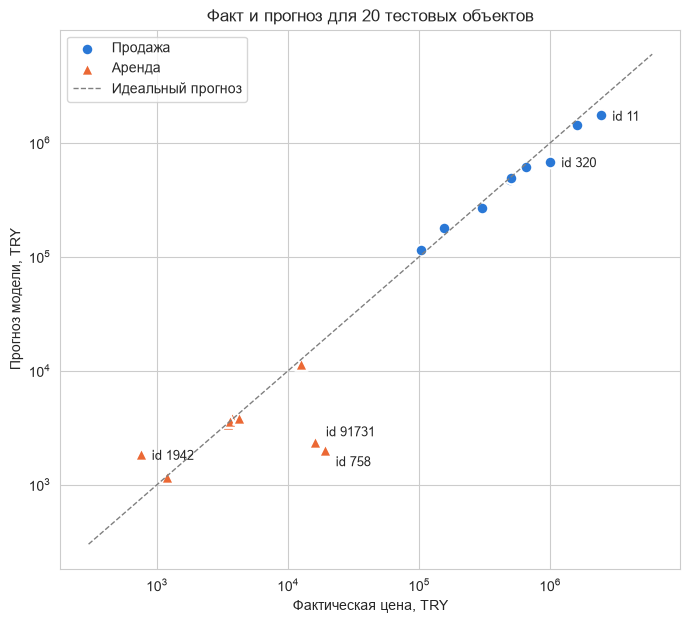

In [64]:
sale = samples['listing_type'] == 1

plt.figure(figsize=(8, 7))
plt.scatter(samples.loc[sale, 'price'], samples.loc[sale, 'predicted_price'],
            s=70, color='#2a78d6', marker='o', edgecolors='white', linewidths=1.5,
            label='Продажа')
plt.scatter(samples.loc[~sale, 'price'], samples.loc[~sale, 'predicted_price'],
            s=80, color='#eb6834', marker='^', edgecolors='white', linewidths=1.5,
            label='Аренда')
plt.plot([300, 6_000_000], [300, 6_000_000], color='grey', linestyle='--',
         linewidth=1, label='Идеальный прогноз')

label_offsets = {11: (8, -4), 320: (8, -4), 1942: (8, -4), 758: (8, -12), 91731: (8, 4)}
for obj_id, offset in label_offsets.items():
    row = samples[samples['id'] == obj_id].iloc[0]
    plt.annotate('id ' + str(obj_id), (row['price'], row['predicted_price']),
                 textcoords='offset points', xytext=offset, fontsize=9)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Фактическая цена, TRY')
plt.ylabel('Прогноз модели, TRY')
plt.title('Факт и прогноз для 20 тестовых объектов')
plt.legend()
plt.show()

In [65]:
# в какую часть разбиения Этапа 2 попал каждый объект
part_by_id = pd.concat([
    pd.Series('train', index=df.loc[X_train.index, 'id']),
    pd.Series('valid', index=df.loc[X_valid.index, 'id']),
    pd.Series('test', index=df.loc[X_test.index, 'id']),
])

analysis = samples[['id', 'listing_type', 'sub_type', 'address', 'size',
                    'price', 'predicted_price']].copy()
analysis['Ошибка, %'] = ((analysis['predicted_price'] - analysis['price'])
                         / analysis['price'] * 100).round(1)
analysis['Часть выборки'] = analysis['id'].map(part_by_id).fillna('удалён при очистке')

analysis

,id,listing_type,sub_type,address,size,price,predicted_price,"Ошибка, %",Часть выборки
0,49,1,Kooperatif,İzmir/Aliağa/Yenişakran,1.0,300000.0,268383.0,-10.5,удалён при очистке
1,506,1,Çiftlik Evi,İzmir/Foça/Yeniköy,250.0,1600000.0,1435708.0,-10.3,test
2,2,1,Daire,İstanbul/Kartal/Kordonboyu,43.0,490000.0,472531.0,-3.6,train
3,528,1,Prefabrik Ev,Tekirdağ/Çerkezköy/Kızılpınar,122.0,103600.0,114154.0,10.2,test
4,109,1,Kooperatif,İzmir/Aliağa/Yenişakran,1.0,300000.0,268383.0,-10.5,удалён при очистке
5,100,1,Yazlık,Mersin/Erdemli/Kargıpınarı,150.0,500000.0,493321.0,-1.3,valid
6,320,1,Yazlık,Balıkesir/Burhaniye/Pelitköy,134.0,1000000.0,683942.0,-31.6,train
7,3,1,Daire,Tekirdağ/Çorlu/Reşadiye,NaN,155000.0,178415.0,15.1,удалён при очистке
8,7810,1,Loft,İzmir/Konak/Akın Simav,145.0,650000.0,614188.0,-5.5,train
9,11,1,Müstakil Ev,Muğla/Bodrum/Ortakentyahşi,125.0,2450000.0,1748558.0,-28.6,train


In [66]:
n_test_sale = (X_test['listing_type'] == 1).sum()

rows = []
for listing_type, name in [(1, 'Тест Этапа 3: продажа'), (2, 'Тест Этапа 3: аренда')]:
    m = package['metrics_by_type'][listing_type]
    rows.append({'Объекты': name,
                 'Количество': n_test_sale if listing_type == 1 else len(X_test) - n_test_sale,
                 'MAE': m['MAE'], 'RMSE': m['RMSE'], 'R2': m['R2']})

parts = {
    'Все 20 объектов': samples,
    'Продажа': samples[sale],
    'Аренда': samples[~sale],
}
for name, part in parts.items():
    row = {'Объекты': name, 'Количество': len(part)}
    row.update(library_metrics(part['price'], part['predicted_price']))
    rows.append(row)

pd.DataFrame(rows).set_index('Объекты').round(2)

,Количество,MAE,RMSE,R2
Объекты,,,,
Тест Этапа 3: продажа,26522,99040.11,331679.27,0.71
Тест Этапа 3: аренда,10290,722.18,2687.70,0.57
Все 20 объектов,20,68610.50,176588.87,0.92
Продажа,10,133895.50,249639.06,0.88
Аренда,10,3325.50,6899.26,-0.25


### Выводы

1. **Ручной расчёт и sklearn совпали** — формулы реализованы верно.
2. **На всех 20 объектах R² = 0.92**, MAE ≈ 69 тыс. лир. Благодаря признаку `listing_type`
   модель различает продажу и аренду: точки обоих типов лежат вдоль линии идеального прогноза.
3. **Продажа: R² = 0.88**, средняя ошибка по модулю — 13%. Объекты, которых модель
   не видела при обучении, предсказаны с ошибкой от 1 до 15%. Сильнее всего занижены
   дорогие дома: `id` 11 в Бодруме (−29%) и летний дом `id` 320 (−32%).
4. **Аренда: MAE ≈ 3.3 тыс. лир, но R² = −0.25.** 7 из 10 объектов предсказаны точнее
   ±10%, но все они были в обучающей выборке. Весь минус дают два дорогих объекта:
   `id` 758 (фермерский дом за 19 000 лир в месяц, прогноз 2 031) и `id` 91731 (лофт
   без указанной площади за 16 000, прогноз 2 372). Без них R² по аренде — 0.97.
   Честная оценка для аренды — тестовая выборка Этапа 3: MAPE 24.9%, R² 0.57.

**Как улучшить:** проверять входные данные (пропуски площади), добавить признаки
для дорогих и нетипичных объектов (вид на море, коммерческое назначение).

## 5.5 Сохранение результата

In [67]:
STUDENT_NAME = 'Баймуратов Данил Азатович'
STUDENT_GROUP = '23п1'

result = samples.copy()
result.insert(result.columns.get_loc('predicted_price'), 'ФИО', STUDENT_NAME)
result.insert(result.columns.get_loc('predicted_price'), 'Группа', STUDENT_GROUP)
result.to_csv('result_real_estate_samples.csv', index=False, encoding='utf-8-sig')

print('Сохранено: result_real_estate_samples.csv')

Сохранено: result_real_estate_samples.csv
